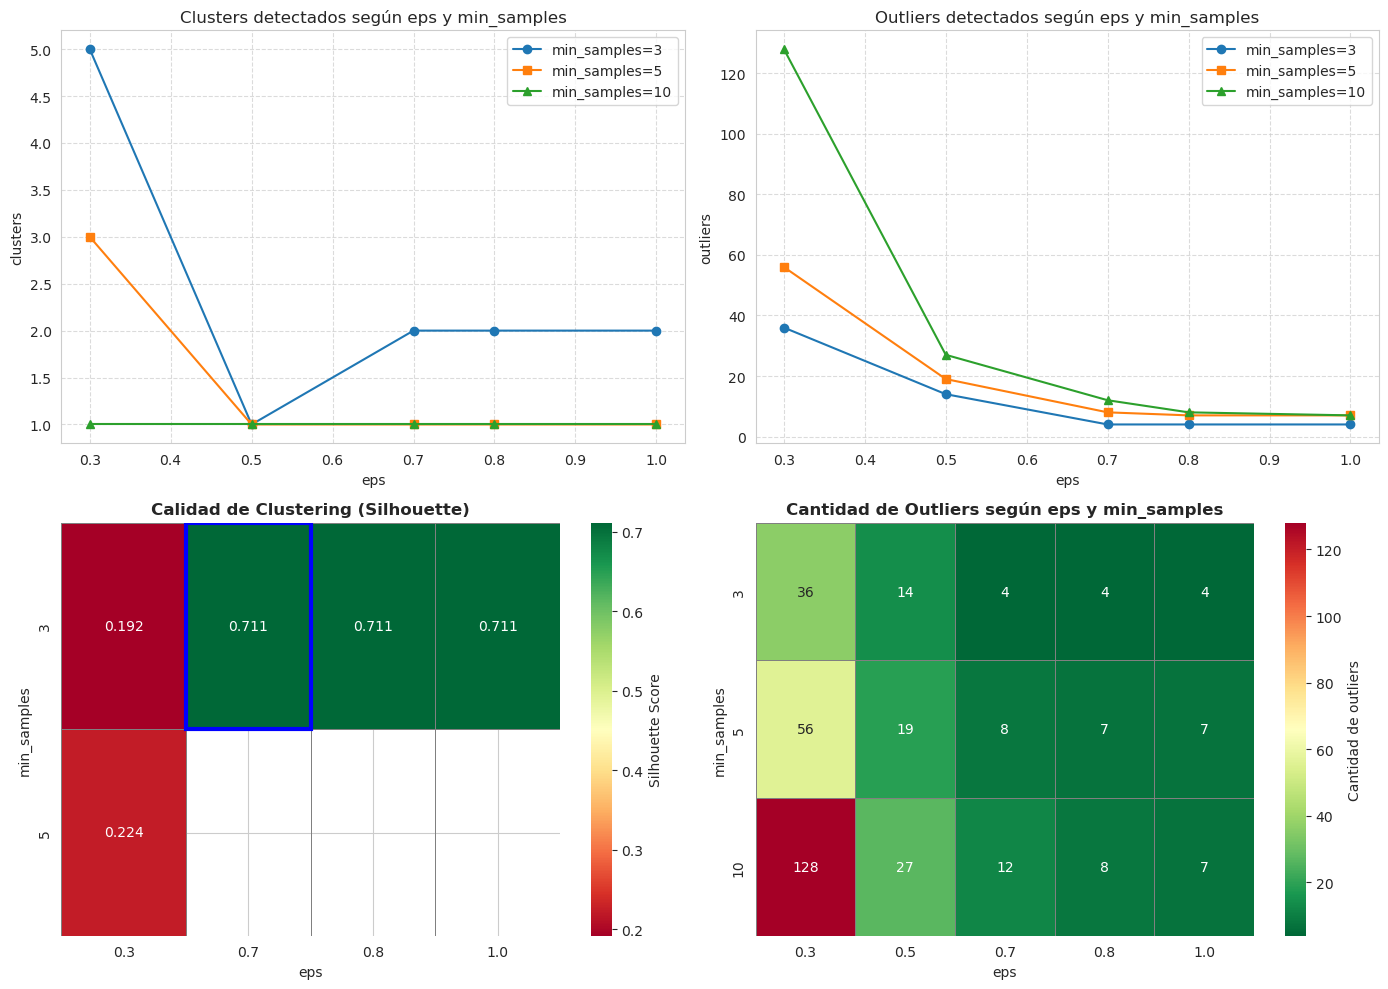


## Conclusión de Experimentos DBSCAN

Tras probar distintas combinaciones de parámetros:
- Mejor configuración encontrada: eps=0.7, min_samples=3.0
- Clusters detectados: 2.0
- Outliers detectados: 4.0
- Silhouette Score: 0.711

Esto sugiere que esta combinación ofrece la separación más clara entre clusters y ruido.  
Sin embargo, los resultados pueden variar según la escala de los datos, por lo que es recomendable seguir ajustando parámetros y validar con métricas adicionales.


In [13]:
# =========================
# LIBRERÍAS
# =========================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sns.set_style("whitegrid")
palette = sns.color_palette("tab10", len(min_samples_values))
markers = ["o", "s", "^"]

# =========================
# SUBPLOTS 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# -------------------------
# Gráfico de clusters
# -------------------------
ax1 = axes[0,0]
for i, min_samples in enumerate(min_samples_values):
    subset = df_results[df_results["min_samples"] == min_samples]
    ax1.plot(subset["eps"], subset["clusters"], 
             marker=markers[i], color=palette[i], 
             label=f"min_samples={min_samples}")
ax1.set_title("Clusters detectados según eps y min_samples")
ax1.set_xlabel("eps")
ax1.set_ylabel("clusters")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.7)

# -------------------------
# Gráfico de outliers
# -------------------------
ax2 = axes[0,1]
for i, min_samples in enumerate(min_samples_values):
    subset = df_results[df_results["min_samples"] == min_samples]
    ax2.plot(subset["eps"], subset["outliers"], 
             marker=markers[i], color=palette[i], 
             label=f"min_samples={min_samples}")
ax2.set_title("Outliers detectados según eps y min_samples")
ax2.set_xlabel("eps")
ax2.set_ylabel("outliers")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.7)

# -------------------------
# Heatmap del Silhouette Score
# -------------------------
df_heatmap = df_results.dropna(subset=["silhouette"])
pivot = df_heatmap.pivot(index="min_samples", columns="eps", values="silhouette")

ax3 = axes[1,0]
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn", 
    cbar_kws={'label': 'Silhouette Score'}, 
    linewidths=0.5, linecolor="gray", ax=ax3
)
ax3.set_title("Calidad de Clustering (Silhouette)", fontsize=12, fontweight="bold")
ax3.set_xlabel("eps")
ax3.set_ylabel("min_samples")

# Resaltar la mejor celda con un rectángulo azul
best = df_heatmap.sort_values("silhouette", ascending=False).iloc[0]
best_x = list(pivot.columns).index(best["eps"])
best_y = list(pivot.index).index(best["min_samples"])
ax3.add_patch(patches.Rectangle((best_x, best_y), 1, 1, fill=False, edgecolor='blue', lw=3))

# -------------------------
# Heatmap de Outliers
# -------------------------
pivot_outliers = df_results.pivot(index="min_samples", columns="eps", values="outliers")

ax4 = axes[1,1]
sns.heatmap(
    pivot_outliers, annot=True, fmt="d", cmap="RdYlGn_r", 
    cbar_kws={'label': 'Cantidad de outliers'}, 
    linewidths=0.5, linecolor="gray", ax=ax4
)
ax4.set_title("Cantidad de Outliers según eps y min_samples", fontsize=12, fontweight="bold")
ax4.set_xlabel("eps")
ax4.set_ylabel("min_samples")

# Ajustar espacios entre subplots
fig.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.show()

# =========================
# CONCLUSIÓN AUTOMÁTICA
# =========================
if df_results.dropna(subset=["silhouette"]).shape[0] > 0:
    best_config = df_results.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]

    conclusion = f"""
## Conclusión de Experimentos DBSCAN

Tras probar distintas combinaciones de parámetros:
- Mejor configuración encontrada: eps={best_config['eps']}, min_samples={best_config['min_samples']}
- Clusters detectados: {best_config['clusters']}
- Outliers detectados: {best_config['outliers']}
- Silhouette Score: {best_config['silhouette']:.3f}

Esto sugiere que esta combinación ofrece la separación más clara entre clusters y ruido.  
Sin embargo, los resultados pueden variar según la escala de los datos, por lo que es recomendable seguir ajustando parámetros y validar con métricas adicionales.
"""
else:
    conclusion = """
## Conclusión de Experimentos DBSCAN

Ninguna configuración probada logró formar más de un cluster válido.  
Esto indica que DBSCAN no fue factible con los parámetros actuales.  
Se recomienda ajustar `eps` y `min_samples` o considerar otro algoritmo de clustering.
"""

display(Markdown(conclusion))

